In [5]:
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb

df = pd.read_csv('data/Batting.csv')


In [6]:
df['1B'] = df['H'] - df['2B'] - df['3B'] - df['HR']
df['1B'] = df['1B'].fillna(0).astype(int)

In [7]:
required_columns = ['BB', 'IBB', 'HBP', '1B', '2B', '3B', 'HR', 'AB', 'SF']
df = df.dropna(subset=required_columns)
df = df[df['AB'] >= 400]

In [8]:
df = df.sort_values(by=['playerID', 'yearID'])
for col in required_columns:
    df[f'{col}_lag1'] = df.groupby('playerID')[col].shift(1)
    df[f'{col}_lag2'] = df.groupby('playerID')[col].shift(2)

lag_features = [f'{col}_lag1' for col in required_columns] + [f'{col}_lag2' for col in required_columns]
df = df.dropna(subset=lag_features)

In [9]:
split_year = 2010
train_df = df[df['yearID'] < split_year]
val_df = df[df['yearID'] >= split_year]

In [10]:
feature_cols = ['HR_lag1', 'HR_lag2']
target_col = 'HR'

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_val = val_df[feature_cols]
y_val = val_df[target_col]

model = xgb.XGBRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)
mse = mean_squared_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print("XGBoost Model Results:")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.3f}")

XGBoost Model Results:
Mean Squared Error: 60.39
R² Score: 0.384


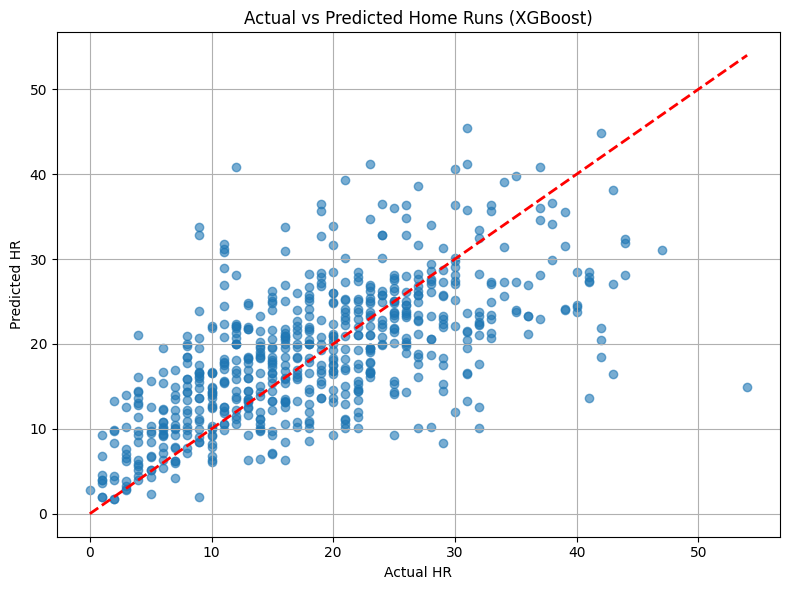

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_val, y_pred, alpha=0.6)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
plt.xlabel('Actual HR')
plt.ylabel('Predicted HR')
plt.title('Actual vs Predicted Home Runs (XGBoost)')
plt.grid(True)
plt.tight_layout()
plt.show()